# 05 — Inference, Debugging, and Business Decisions (PyTorch)

A useful model must be evaluated on unseen data, inspected for systematic errors, and embedded in a decision policy.


train (5000, 784) test (1000, 784)


              precision    recall  f1-score   support

           0      0.633     0.950     0.760       100
           1      0.648     0.940     0.767       100
           2      0.891     0.410     0.562       100
           3      0.648     0.810     0.720       100
           4      0.818     0.540     0.651       100
           5      0.654     0.340     0.447       100
           6      0.652     0.880     0.749       100
           7      0.837     0.770     0.802       100
           8      0.423     0.580     0.489       100
           9      0.827     0.430     0.566       100

    accuracy                          0.665      1000
   macro avg      0.703     0.665     0.651      1000
weighted avg      0.703     0.665     0.651      1000



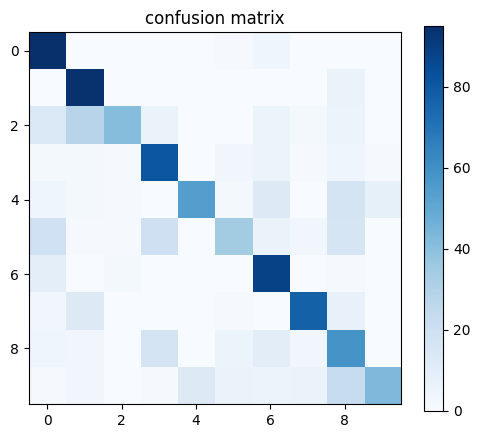

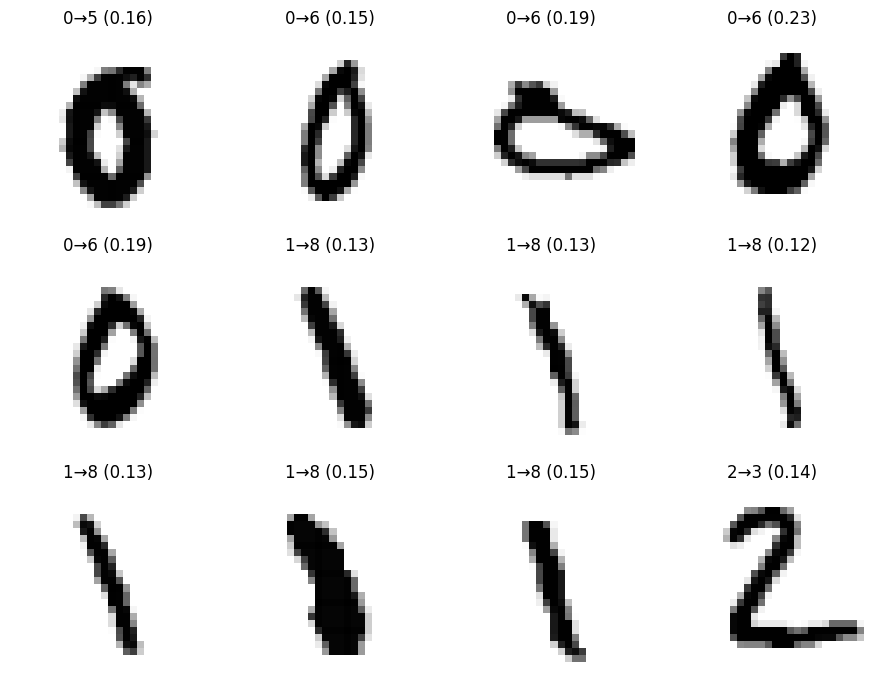

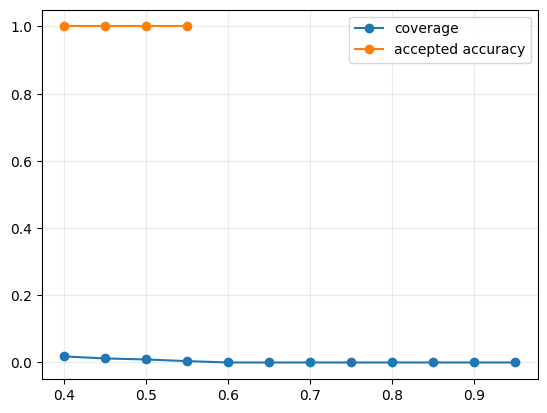

In [1]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import torch,torch.nn as nn,matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report
torch.manual_seed(42);X=torch.tensor(x_train);Y=torch.tensor(y_train,dtype=torch.long);Xt=torch.tensor(x_test);model=nn.Sequential(nn.Linear(784,64),nn.ReLU(),nn.Linear(64,10));opt=torch.optim.SGD(model.parameters(),lr=.25);crit=nn.CrossEntropyLoss()
for _ in range(10):opt.zero_grad();loss=crit(model(X),Y);loss.backward();opt.step()
with torch.no_grad():p=torch.softmax(model(Xt),1);pred=p.argmax(1).numpy();conf=p.max(1).values.numpy()
print(classification_report(y_test,pred,digits=3));cm=confusion_matrix(y_test,pred);plt.figure(figsize=(6,5));plt.imshow(cm,cmap='Blues');plt.colorbar();plt.title('confusion matrix');plt.show();wrong=np.flatnonzero(pred!=y_test)[:12];fig,axes=plt.subplots(3,4,figsize=(9,7))
for ax,i in zip(axes.ravel(),wrong):ax.imshow(x_test_img[i],cmap='gray_r');ax.set_title(f'{y_test[i]}→{pred[i]} ({conf[i]:.2f})');ax.axis('off')
plt.tight_layout();plt.show();ths=np.linspace(.4,.95,12);cov=[];acc=[]
for t in ths:m=conf>=t;cov.append(m.mean());acc.append((pred[m]==y_test[m]).mean() if m.any() else np.nan)
plt.plot(ths,cov,marker='o',label='coverage');plt.plot(ths,acc,marker='o',label='accepted accuracy');plt.legend();plt.grid(alpha=.25);plt.show()


## Confidence is not correctness
A normalized softmax score is not a guarantee. Wrong predictions can still be confident. In production, low-confidence cases may be routed to review, while high-risk systems may require calibration and explicit abstention.


## Business interpretation
Imagine MNIST-like digit recognition inside document ingestion. Raising the confidence threshold can improve automated-decision accuracy while reducing automation coverage and increasing manual-review volume.

The operational optimum depends on **error cost + review capacity + latency + risk tolerance**, not accuracy alone.

### Final mental model
- forward pass = current belief
- loss = quantified error
- backprop = responsibility assignment
- update = parameter correction
- representation learning = changing hidden geometry
- inference = applying the learned function to unseen data
- business policy = turning model scores into actions
